# VN-Index + SVI Daily Pipeline

Notebook này được viết lại từ đầu theo 3 phase rõ ràng: Load data, Data engineer, EDA. Mục tiêu là tách in-sample 2010-2025 và out-of-sample từ 2026-nay, fit PCA chỉ trên in-sample để tránh leakage, rồi xuất hai file riêng `insample_data` và `outofsample_data`.

## Phase 0. Setup

Trước khi đi vào mô hình, cần khóa chặt chất lượng dữ liệu gốc. VN-Index đóng vai trò lịch giao dịch chuẩn, còn Google Trends sẽ được lấy riêng cho in-sample và out-of-sample theo mốc 2025-12-31 / 2026-01-01, sau đó PCA chỉ fit trên in-sample.

### Import libraries and set constants

In [1]:
import sys
import time
import warnings
from dataclasses import dataclass
from pathlib import Path
from typing import Dict, List, Optional, Tuple

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import vnstock as vns
from IPython.display import display
from pandas.errors import EmptyDataError
from pytrends.exceptions import TooManyRequestsError
from pytrends.request import TrendReq
from sklearn.decomposition import PCA

warnings.filterwarnings("ignore")

📦 **Vnstock 3.5.1 is available**
Current: 3.5.0 (Python 3.11 (venv))
Update: `d:\code\Python\DSEB_ex\TimeSeries\.venv\Scripts\python.exe -m pip install vnstock --upgrade`
Release: https://vnstocks.com/docs/tai-lieu/lich-su-phien-ban

📦 **Vnai 2.4.6 is available**
Current: 2.4.0 (Python 3.11 (venv))
Update: `d:\code\Python\DSEB_ex\TimeSeries\.venv\Scripts\python.exe -m pip install vnai --upgrade`
Release: https://pypi.org/project/vnai/#history

In [2]:
@dataclass
class DataConfig:
    symbol: str = "VNINDEX"
    fallback_symbols: Tuple[str, ...] = ("VN-INDEX", "VNI")
    price_source: str = "VCI"
    insample_start_date: str = "2010-01-01"
    insample_end_date: str = "2025-12-31"
    outsample_start_date: str = "2026-01-01"
    outsample_end_date: Optional[str] = "2026-03-31"
    keywords: Tuple[str, ...] = ("chung khoan", "VN-Index", "co phieu", "dau tu")
    geo: str = "VN"
    hl: str = "en-US"
    tz: int = 420

    trend_window_days: int = 240
    trend_overlap_days: int = 14
    trend_sleep_seconds: float = 8.0
    trend_max_retries: int = 5
    trend_backoff_base_seconds: float = 5.0
    trend_backoff_max_seconds: float = 10.0
    api_sleep_seconds: float = 1.5
    api_max_retries: int = 4
    api_backoff_base_seconds: float = 2.0
    api_backoff_max_seconds: float = 30.0

    cache_dir: str = "outputs/trends_cache"
    data_dir: str = "data"
    insample_filename: str = "insample_data.csv"
    outsample_filename: str = "outofsample_data.csv"

    update_insample_file: bool = True
    update_outsample_file: bool = True


CONFIG = DataConfig()
OUTPUT_DIR = Path(CONFIG.data_dir)
CACHE_DIR = Path(CONFIG.cache_dir)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
CACHE_DIR.mkdir(parents=True, exist_ok=True)

print("Python:", sys.version.split()[0])
print("pandas:", pd.__version__)
print("numpy:", np.__version__)
# print(json.dumps(asdict(CONFIG), indent=2))

Python: 3.11.4
pandas: 3.0.0
numpy: 2.4.1


### Helper functions

In [3]:
def get_date_bounds(config: DataConfig, split: str) -> Tuple[pd.Timestamp, pd.Timestamp]:
    if split == "insample":
        return pd.Timestamp(config.insample_start_date), pd.Timestamp(config.insample_end_date)

    if split == "outsample":
        end_date = config.outsample_end_date or pd.Timestamp.today().normalize().strftime("%Y-%m-%d")
        return pd.Timestamp(config.outsample_start_date), pd.Timestamp(end_date)

    raise ValueError(f"Unknown split: {split}")


def _sleep_with_backoff(attempt: int, base_seconds: float, max_seconds: float) -> None:
    wait_seconds = min(base_seconds * (2 ** max(0, attempt - 1)), max_seconds)
    time.sleep(wait_seconds)


def _normalize_datetime_index(index: pd.Index) -> pd.DatetimeIndex:
    dt_index = pd.to_datetime(index)
    if getattr(dt_index, "tz", None) is not None:
        dt_index = dt_index.tz_localize(None)
    return pd.DatetimeIndex(dt_index)


def _api_call_with_retry(call_fn, *, call_name: str, max_retries: int, base_backoff: float, max_backoff: float):
    last_error: Optional[Exception] = None
    for attempt in range(1, max_retries + 1):
        try:
            return call_fn()
        except Exception as exc:
            last_error = exc
            if attempt == max_retries:
                break
            _sleep_with_backoff(attempt, base_backoff, max_backoff)
    raise RuntimeError(f"API call failed after retries: {call_name}") from last_error


def _normalize_price_frame(df: pd.DataFrame, config: DataConfig, start_ts: pd.Timestamp, end_ts: pd.Timestamp, symbol_used: str) -> pd.DataFrame:
    lowered = {col.lower(): col for col in df.columns}
    date_col = lowered.get("time") or lowered.get("date") or lowered.get("datetime")
    open_col = lowered.get("open")
    high_col = lowered.get("high")
    low_col = lowered.get("low")
    close_col = lowered.get("close") or lowered.get("adj close") or lowered.get("adj_close")
    if date_col is None or open_col is None or high_col is None or low_col is None or close_col is None:
        raise ValueError(f"Unexpected vnstock columns for OHLC extraction: {list(df.columns)}")

    out = df[[date_col, open_col, high_col, low_col, close_col]].copy()
    out.columns = ["date", "open", "high", "low", "close"]
    out["date"] = pd.to_datetime(out["date"], errors="coerce")
    for col in ["open", "high", "low", "close"]:
        out[col] = pd.to_numeric(out[col], errors="coerce")
    out = out.dropna(subset=["date", "open", "high", "low", "close"])
    out = out.set_index("date").sort_index()
    out = out.loc[(out.index >= start_ts) & (out.index <= end_ts)]
    out["symbol_used"] = symbol_used
    out.index.name = "date"
    return out


def _download_vnindex(symbol: str, config: DataConfig, start_ts: pd.Timestamp, end_ts: pd.Timestamp) -> pd.DataFrame:
    start_str = start_ts.strftime("%Y-%m-%d")
    end_str = end_ts.strftime("%Y-%m-%d")

    def legacy_loader() -> pd.DataFrame:
        return vns.stock_historical_data(
            symbol=symbol,
            start_date=start_str,
            end_date=end_str,
            resolution="1D",
            type="index",
            source=config.price_source,
            beautify=False,
            decor=False,
        )

    def legacy_fallback_loader() -> pd.DataFrame:
        return vns.stock_historical_data(
            symbol=symbol,
            start_date=start_str,
            end_date=end_str,
            resolution="1D",
            type="index",
        )

    def new_api_loader() -> pd.DataFrame:
        client = vns.Vnstock()
        quote = client.stock(symbol=symbol, source=config.price_source).quote
        return quote.history(start=start_str, end=end_str, interval="1D")

    if hasattr(vns, "stock_historical_data"):
        try:
            hist = _api_call_with_retry(
                legacy_loader,
                call_name=f"vnstock.stock_historical_data({symbol})",
                max_retries=config.api_max_retries,
                base_backoff=config.api_backoff_base_seconds,
                max_backoff=config.api_backoff_max_seconds,
            )
            time.sleep(config.api_sleep_seconds)
            if isinstance(hist, pd.DataFrame) and not hist.empty:
                return hist
        except TypeError:
            hist = _api_call_with_retry(
                legacy_fallback_loader,
                call_name=f"vnstock.stock_historical_data fallback({symbol})",
                max_retries=config.api_max_retries,
                base_backoff=config.api_backoff_base_seconds,
                max_backoff=config.api_backoff_max_seconds,
            )
            time.sleep(config.api_sleep_seconds)
            if isinstance(hist, pd.DataFrame) and not hist.empty:
                return hist

    if hasattr(vns, "Vnstock"):
        hist = _api_call_with_retry(
            new_api_loader,
            call_name=f"vnstock.Vnstock().quote.history({symbol})",
            max_retries=config.api_max_retries,
            base_backoff=config.api_backoff_base_seconds,
            max_backoff=config.api_backoff_max_seconds,
        )
        time.sleep(config.api_sleep_seconds)
        if isinstance(hist, pd.DataFrame) and not hist.empty:
            return hist

    return pd.DataFrame()


def fetch_vnindex_prices(config: DataConfig, start_ts: pd.Timestamp, end_ts: pd.Timestamp) -> pd.DataFrame:
    candidates = [config.symbol] + [symbol for symbol in config.fallback_symbols if symbol != config.symbol]
    errors: List[str] = []

    for symbol in candidates:
        try:
            raw = _download_vnindex(symbol, config, start_ts, end_ts)
            if raw.empty:
                errors.append(f"{symbol}: empty dataframe")
                continue
            out = _normalize_price_frame(raw, config, start_ts, end_ts, symbol)
            if out.empty:
                errors.append(f"{symbol}: empty after cleaning")
                continue
            return out
        except Exception as exc:
            errors.append(f"{symbol}: {type(exc).__name__} - {exc}")

    raise ValueError("No VN-Index data returned from vnstock. " + " | ".join(errors))


def _trend_cache_path(config: DataConfig, keyword: str, start_ts: pd.Timestamp, end_ts: pd.Timestamp) -> Path:
    safe_keyword = "".join(ch if ch.isalnum() else "_" for ch in keyword)
    filename = f"{safe_keyword}_{start_ts.strftime('%Y%m%d')}_{end_ts.strftime('%Y%m%d')}.csv"
    return Path(config.cache_dir) / filename


def build_date_windows(start_ts: pd.Timestamp, end_ts: pd.Timestamp, window_days: int, overlap_days: int) -> List[Tuple[pd.Timestamp, pd.Timestamp]]:
    if overlap_days >= window_days:
        raise ValueError("overlap_days must be smaller than window_days")

    windows: List[Tuple[pd.Timestamp, pd.Timestamp]] = []
    step = window_days - overlap_days
    current_start = start_ts

    while current_start <= end_ts:
        current_end = min(current_start + pd.Timedelta(days=window_days - 1), end_ts)
        windows.append((current_start, current_end))
        if current_end >= end_ts:
            break
        current_start = current_start + pd.Timedelta(days=step)

    return windows


def stitch_overlapping_series(chunks: List[pd.Series]) -> pd.Series:
    if not chunks:
        return pd.Series(dtype=float)

    stitched = chunks[0].copy()
    for next_series in chunks[1:]:
        overlap_index = stitched.index.intersection(next_series.index)
        if len(overlap_index) > 0:
            prev_mean = stitched.loc[overlap_index].replace(0, np.nan).mean()
            next_mean = next_series.loc[overlap_index].replace(0, np.nan).mean()
            factor = prev_mean / next_mean if pd.notna(prev_mean) and pd.notna(next_mean) and next_mean > 0 else 1.0
        else:
            factor = 1.0
        scaled_next = next_series * factor
        stitched = pd.concat([stitched, scaled_next[~scaled_next.index.isin(stitched.index)]])
        stitched = stitched.sort_index()

    return stitched


def fetch_trend_window(pytrends: TrendReq, keyword: str, start_ts: pd.Timestamp, end_ts: pd.Timestamp, config: DataConfig) -> pd.Series:
    cache_path = _trend_cache_path(config, keyword, start_ts, end_ts)
    if cache_path.exists():
        try:
            cached = pd.read_csv(cache_path, index_col=0, parse_dates=True)
        except EmptyDataError:
            cached = pd.DataFrame()
        if not cached.empty and keyword in cached.columns:
            series = cached[keyword].astype(float)
            series.index = _normalize_datetime_index(series.index)
            series.name = keyword
            return series

    timeframe = f"{start_ts.strftime('%Y-%m-%d')} {end_ts.strftime('%Y-%m-%d')}"
    for attempt in range(1, config.trend_max_retries + 1):
        try:
            pytrends.build_payload([keyword], timeframe=timeframe, geo=config.geo)
            data = pytrends.interest_over_time()
            time.sleep(config.trend_sleep_seconds)
            if data.empty or keyword not in data.columns:
                return pd.Series(dtype=float, name=keyword)
            series = data[keyword].astype(float)
            series.index = _normalize_datetime_index(series.index)
            series.name = keyword
            pd.DataFrame({keyword: series}).to_csv(cache_path)
            return series
        except TooManyRequestsError:
            if attempt == config.trend_max_retries:
                raise RuntimeError(f"Google Trends rate limit persisted for {keyword} in {timeframe}")
            wait_seconds = min(config.trend_backoff_base_seconds * (2 ** (attempt - 1)), config.trend_backoff_max_seconds)
            print(f"429 for {keyword} [{timeframe}] attempt {attempt}/{config.trend_max_retries}, waiting {wait_seconds:.1f}s")
            time.sleep(wait_seconds)

    return pd.Series(dtype=float, name=keyword)


def build_keyword_panel(config: DataConfig, start_ts: pd.Timestamp, end_ts: pd.Timestamp) -> pd.DataFrame:
    pytrends = TrendReq(hl=config.hl, tz=config.tz)
    keyword_series = {}

    for keyword in config.keywords:
        windows = build_date_windows(start_ts, end_ts, config.trend_window_days, config.trend_overlap_days)
        chunks: List[pd.Series] = []
        for window_start, window_end in windows:
            series = fetch_trend_window(pytrends, keyword, window_start, window_end, config)
            if not series.empty:
                chunks.append(series)
        stitched = stitch_overlapping_series(chunks)
        stitched = stitched.loc[(stitched.index >= start_ts) & (stitched.index <= end_ts)]
        stitched.name = keyword
        keyword_series[keyword] = stitched

    keyword_df = pd.DataFrame(keyword_series).sort_index()
    keyword_df.index.name = "date"
    return keyword_df


def fit_svi_from_keywords(keyword_df: pd.DataFrame) -> Tuple[pd.DataFrame, Dict[str, object]]:
    if keyword_df.empty:
        raise ValueError("No Google Trends data loaded.")

    keyword_df = keyword_df.sort_index().copy()
    keyword_means = keyword_df.mean()
    keyword_stds = keyword_df.std(ddof=0).replace(0, np.nan)
    standardized = ((keyword_df - keyword_means) / keyword_stds).replace([np.inf, -np.inf], np.nan).dropna(how="any")
    if standardized.empty:
        raise ValueError("No valid rows remain after keyword standardization.")

    pca = PCA(n_components=1)
    pc1 = pca.fit_transform(standardized.values).reshape(-1)
    svi = pd.Series(pc1, index=standardized.index, name="SVI")

    reference = standardized.mean(axis=1)
    common_index = svi.index.intersection(reference.index)
    sign_multiplier = 1.0
    if len(common_index) > 10 and svi.loc[common_index].corr(reference.loc[common_index]) < 0:
        sign_multiplier = -1.0

    svi = svi * sign_multiplier
    svi = svi.rolling(3, min_periods=1).mean()
    svi_df = pd.DataFrame({"SVI": svi}).sort_index()
    meta = {
        "keyword_columns": list(keyword_df.columns),
        "keyword_means": keyword_means,
        "keyword_stds": keyword_stds,
        "pca": pca,
        "sign_multiplier": sign_multiplier,
        "explained_variance_ratio": float(pca.explained_variance_ratio_[0]),
        "pc1_loadings": pd.Series(pca.components_[0], index=standardized.columns).sort_values(ascending=False).to_dict(),
    }
    return svi_df, meta


def transform_svi_with_fitted_pca(keyword_df: pd.DataFrame, svi_meta: Dict[str, object]) -> pd.DataFrame:
    if keyword_df.empty:
        return pd.DataFrame(columns=["SVI"])

    keyword_columns = list(svi_meta["keyword_columns"])
    aligned = keyword_df.reindex(columns=keyword_columns)
    standardized = ((aligned - svi_meta["keyword_means"]) / svi_meta["keyword_stds"]).replace([np.inf, -np.inf], np.nan).dropna(how="any")
    if standardized.empty:
        return pd.DataFrame(columns=["SVI"])

    pca: PCA = svi_meta["pca"]
    pc1 = pca.transform(standardized.values).reshape(-1)
    svi = pd.Series(pc1 * float(svi_meta["sign_multiplier"]), index=standardized.index, name="SVI")
    svi = svi.rolling(3, min_periods=1).mean()
    return pd.DataFrame({"SVI": svi}).sort_index()


def build_split_panels(config: DataConfig):
    insample_start_ts, insample_end_ts = get_date_bounds(config, "insample")
    outsample_start_ts, outsample_end_ts = get_date_bounds(config, "outsample")

    price_insample = fetch_vnindex_prices(config, insample_start_ts, insample_end_ts)
    keyword_insample = build_keyword_panel(config, insample_start_ts, insample_end_ts)
    svi_insample, svi_meta = fit_svi_from_keywords(keyword_insample)
    insample_panel = price_insample.join(keyword_insample, how="left").join(svi_insample, how="left")
    insample_panel.index.name = "date"

    price_outsample = fetch_vnindex_prices(config, outsample_start_ts, outsample_end_ts)
    keyword_outsample = build_keyword_panel(config, outsample_start_ts, outsample_end_ts)
    svi_outsample = transform_svi_with_fitted_pca(keyword_outsample, svi_meta)
    outsample_panel = price_outsample.join(keyword_outsample, how="left").join(svi_outsample, how="left")
    outsample_panel.index.name = "date"

    return price_insample, keyword_insample, insample_panel, price_outsample, keyword_outsample, outsample_panel, svi_meta


def summarize_data(df: pd.DataFrame, name: str) -> pd.Series:
    summary = pd.Series({
        "name": name,
        "rows": df.shape[0],
        "columns": df.shape[1],
        "missing_values": int(df.isna().sum().sum()),
        "duplicate_index": int(df.index.duplicated().sum()),
        "start": df.index.min(),
        "end": df.index.max(),
    })
    print(summary.to_string())
    return summary


def check_basic_quality(df: pd.DataFrame, name: str) -> None:
    print(f"\nQuality check for {name}")
    summarize_data(df, name)
    if df.index.duplicated().any():
        raise ValueError(f"Duplicated index values found in {name}")

## Phase 1. Data loading rationale

Ở bước này, ta chỉ tạo panel dữ liệu thô và kiểm tra chất lượng nền. Về mặt kinh tế lượng, đây là bước xác nhận lịch giao dịch, mức độ khớp thời gian của chuỗi, và việc dữ liệu có đủ sạch để đi vào các phép biến đổi phi tuyến như PCA và lagging hay không.

In [4]:
price_insample, keyword_insample, insample_panel, price_outsample, keyword_outsample, outsample_panel, svi_meta = build_split_panels(CONFIG)

check_basic_quality(price_insample, "insample_prices")
check_basic_quality(keyword_insample, "insample_google_trends_keywords")
check_basic_quality(insample_panel, "insample_raw_panel")
check_basic_quality(price_outsample, "outsample_prices")
check_basic_quality(keyword_outsample, "outsample_google_trends_keywords")
check_basic_quality(outsample_panel, "outsample_raw_panel")

insample_start_ts = pd.Timestamp(CONFIG.insample_start_date)
insample_end_ts = pd.Timestamp(CONFIG.insample_end_date)
outsample_start_ts = pd.Timestamp(CONFIG.outsample_start_date)
outsample_end_ts = pd.Timestamp(CONFIG.outsample_end_date or pd.Timestamp.today().normalize().strftime("%Y-%m-%d"))

assert insample_panel.index.max() <= insample_end_ts
assert outsample_panel.index.min() >= outsample_start_ts
assert insample_panel.index.max() < outsample_panel.index.min()

print(f"Insample range:  {insample_panel.index.min().date()} -> {insample_panel.index.max().date()}")
print(f"Outsample range: {outsample_panel.index.min().date()} -> {outsample_panel.index.max().date()}")
print("Split boundary check passed: max(insample_date) < min(outsample_date)")

display(price_insample.head())
display(keyword_insample.head())
display(pd.Series({
    "explained_variance_ratio": svi_meta["explained_variance_ratio"],
    "sign_multiplier": svi_meta["sign_multiplier"],
}))

missing_by_column_insample = insample_panel.isna().sum().sort_values(ascending=False)
missing_by_column_outsample = outsample_panel.isna().sum().sort_values(ascending=False)
print("Missing values by column (insample):\n", missing_by_column_insample.to_string())
print("\nMissing values by column (outsample):\n", missing_by_column_outsample.to_string())
print("\nDuplicate index count (insample):", int(insample_panel.index.duplicated().sum()))
print("Duplicate index count (outsample):", int(outsample_panel.index.duplicated().sum()))

2026-04-08 16:11:06 - vnstock.common.data - INFO - Not a stock. Company and finance data unavailable.
2026-04-08 16:11:11 - vnstock.common.data - INFO - Not a stock. Company and finance data unavailable.



Quality check for insample_prices
name                   insample_prices
rows                              3993
columns                              5
missing_values                       0
duplicate_index                      0
start              2010-01-04 00:00:00
end                2025-12-31 00:00:00

Quality check for insample_google_trends_keywords
name               insample_google_trends_keywords
rows                                          5844
columns                                          4
missing_values                                   0
duplicate_index                                  0
start                          2010-01-01 00:00:00
end                            2025-12-31 00:00:00

Quality check for insample_raw_panel
name                insample_raw_panel
rows                              3993
columns                             10
missing_values                       0
duplicate_index                      0
start              2010-01-04 00:00:00
end         

,open,high,low,close,symbol_used
date,,,,,
2010-01-04,501.7,517.1,501.7,517.1,VNINDEX
2010-01-05,538.8,539.4,530.2,532.5,VNINDEX
2010-01-06,527.4,538.8,526.4,534.5,VNINDEX
2010-01-07,536.8,540.8,530.7,533.3,VNINDEX
2010-01-08,541.0,544.5,520.9,520.9,VNINDEX


,chung khoan,VN-Index,co phieu,dau tu
date,,,,
2010-01-01,28.0,0.0,0.0,37.0
2010-01-02,22.0,0.0,0.0,39.0
2010-01-03,21.0,0.0,37.0,43.0
2010-01-04,81.0,0.0,59.0,67.0
2010-01-05,93.0,0.0,48.0,65.0


explained_variance_ratio    0.528394
sign_multiplier             1.000000
dtype: float64

Missing values by column (insample):
 open           0
high           0
low            0
close          0
symbol_used    0
chung khoan    0
VN-Index       0
co phieu       0
dau tu         0
SVI            0

Missing values by column (outsample):
 open           0
high           0
low            0
close          0
symbol_used    0
chung khoan    0
VN-Index       0
co phieu       0
dau tu         0
SVI            0

Duplicate index count (insample): 0
Duplicate index count (outsample): 0


## Phase 2. Data engineer

Sau khi dữ liệu gốc đã được tách theo mốc thời gian, ta tạo các biến kinh tế lượng cốt lõi cho modeling ở file sau. Ở notebook này, phase engineer chỉ tập trung tạo bộ biến nền (`return`, `target`, `SVI`, `SVI_pos`, `SVI_neg`) cho in-sample và out-of-sample, rồi xuất `insample_data` và `outofsample_data` riêng biệt.

In [5]:
def engineer_daily_dataset(panel: pd.DataFrame) -> pd.DataFrame:
    df = panel.copy().sort_index()
    df["return"] = 100.0 * np.log(df["close"] / df["close"].shift(1))

    # Garman-Klass volatility proxy in percent-squared units.
    log_hl = np.log(df["high"] / df["low"])
    log_co = np.log(df["close"] / df["open"])
    gk_var = 0.5 * (log_hl ** 2) - (2.0 * np.log(2.0) - 1.0) * (log_co ** 2)
    df["target"] = (100.0 ** 2) * gk_var.clip(lower=np.finfo(float).eps)

    df["SVI_pos"] = df["SVI"] * df["return"].clip(lower=0)
    df["SVI_neg"] = df["SVI"] * (-df["return"].clip(upper=0))

    final_df = df[["close", "return", "target", "SVI", "SVI_pos", "SVI_neg"]].dropna().copy()
    final_df.index.name = "date"
    return final_df


def export_dataset(df: pd.DataFrame, config: DataConfig, filename: str, overwrite: bool = False) -> Path:
    final_path = Path(config.data_dir) / filename
    if final_path.exists() and not overwrite:
        print(f"Skip overwrite for existing file: {final_path}")
        return final_path

    df.to_csv(final_path, index=True)
    print(f"Saved dataset to: {final_path}")
    return final_path


insample_df = engineer_daily_dataset(insample_panel)
outsample_df = engineer_daily_dataset(outsample_panel)

insample_path = export_dataset(insample_df, CONFIG, CONFIG.insample_filename, overwrite=CONFIG.update_insample_file)
outsample_path = export_dataset(outsample_df, CONFIG, CONFIG.outsample_filename, overwrite=CONFIG.update_outsample_file)

print("Insample shape:", insample_df.shape)
print("Insample columns:", list(insample_df.columns))
print("Outsample shape:", outsample_df.shape)
print("Outsample columns:", list(outsample_df.columns))
display(insample_df.head())
display(outsample_df.head())

Saved dataset to: data\insample_data.csv
Saved dataset to: data\outofsample_data.csv
Insample shape: (3992, 6)
Insample columns: ['close', 'return', 'target', 'SVI', 'SVI_pos', 'SVI_neg']
Outsample shape: (56, 6)
Outsample columns: ['close', 'return', 'target', 'SVI', 'SVI_pos', 'SVI_neg']


,close,return,target,SVI,SVI_pos,SVI_neg
date,,,,,,
2010-01-05,532.5,2.934662,0.945360,4.986535,14.633793,-0.000000
2010-01-06,534.5,0.374883,2.019724,6.631942,2.486204,-0.000000
2010-01-07,533.3,-0.224761,1.611811,6.720395,0.000000,1.510485
2010-01-08,520.9,-2.352603,4.279404,6.871988,0.000000,16.167061
2010-01-11,515.1,-1.119703,1.787010,4.530968,0.000000,5.073338


,close,return,target,SVI,SVI_pos,SVI_neg
date,,,,,,
2026-01-06,1816.27,1.546358,0.581512,3.265351,5.049403,-0.000000
2026-01-07,1861.58,2.464064,1.679833,5.108194,12.586917,-0.000000
2026-01-08,1855.56,-0.323905,1.384860,5.189378,0.000000,1.680866
2026-01-09,1867.90,0.662827,0.993521,5.246393,3.477450,-0.000000
2026-01-12,1877.33,0.503575,0.503008,2.498868,1.258367,-0.000000


## Phase 3. EDA

Giai đoạn EDA không nhằm tối ưu mô hình, mà kiểm tra xem chuỗi có đúng trực giác kinh tế lượng hay không: keyword có đồng biến hay không, return có cụm biến động hay không, SVI có đi cùng proxy volatility hay không, và tác động của SVI khi return dương/âm có khác nhau hay không.

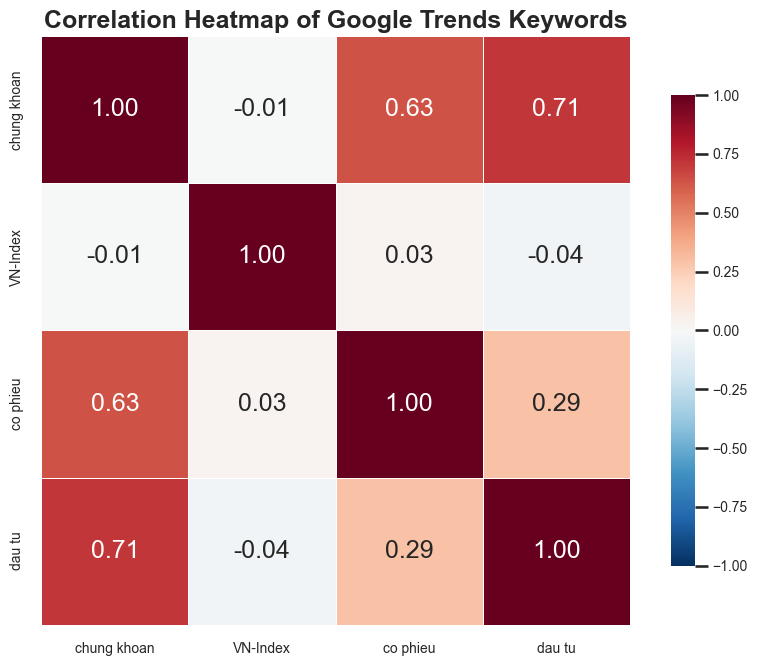

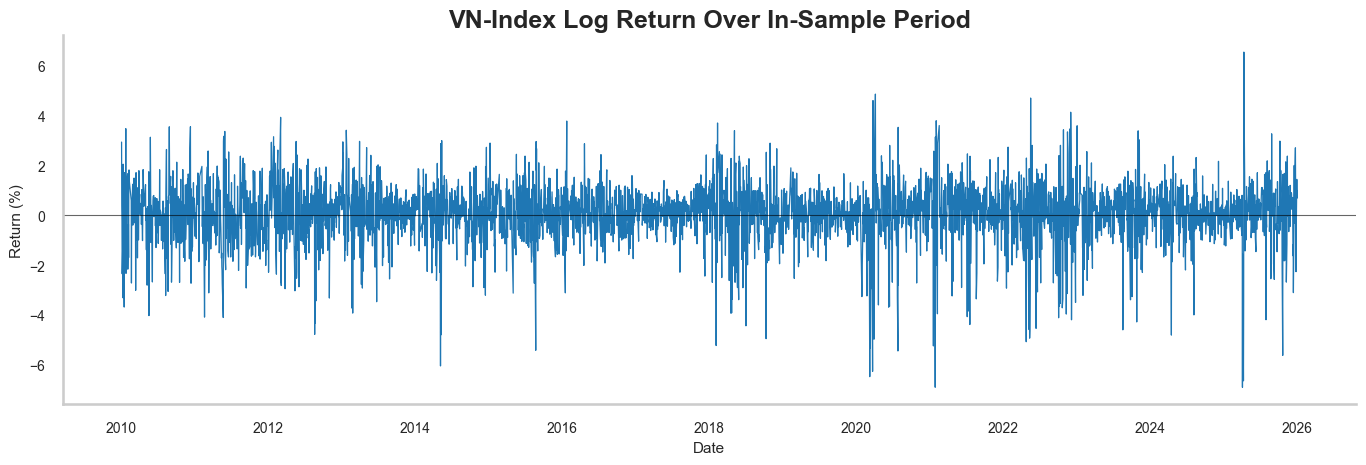

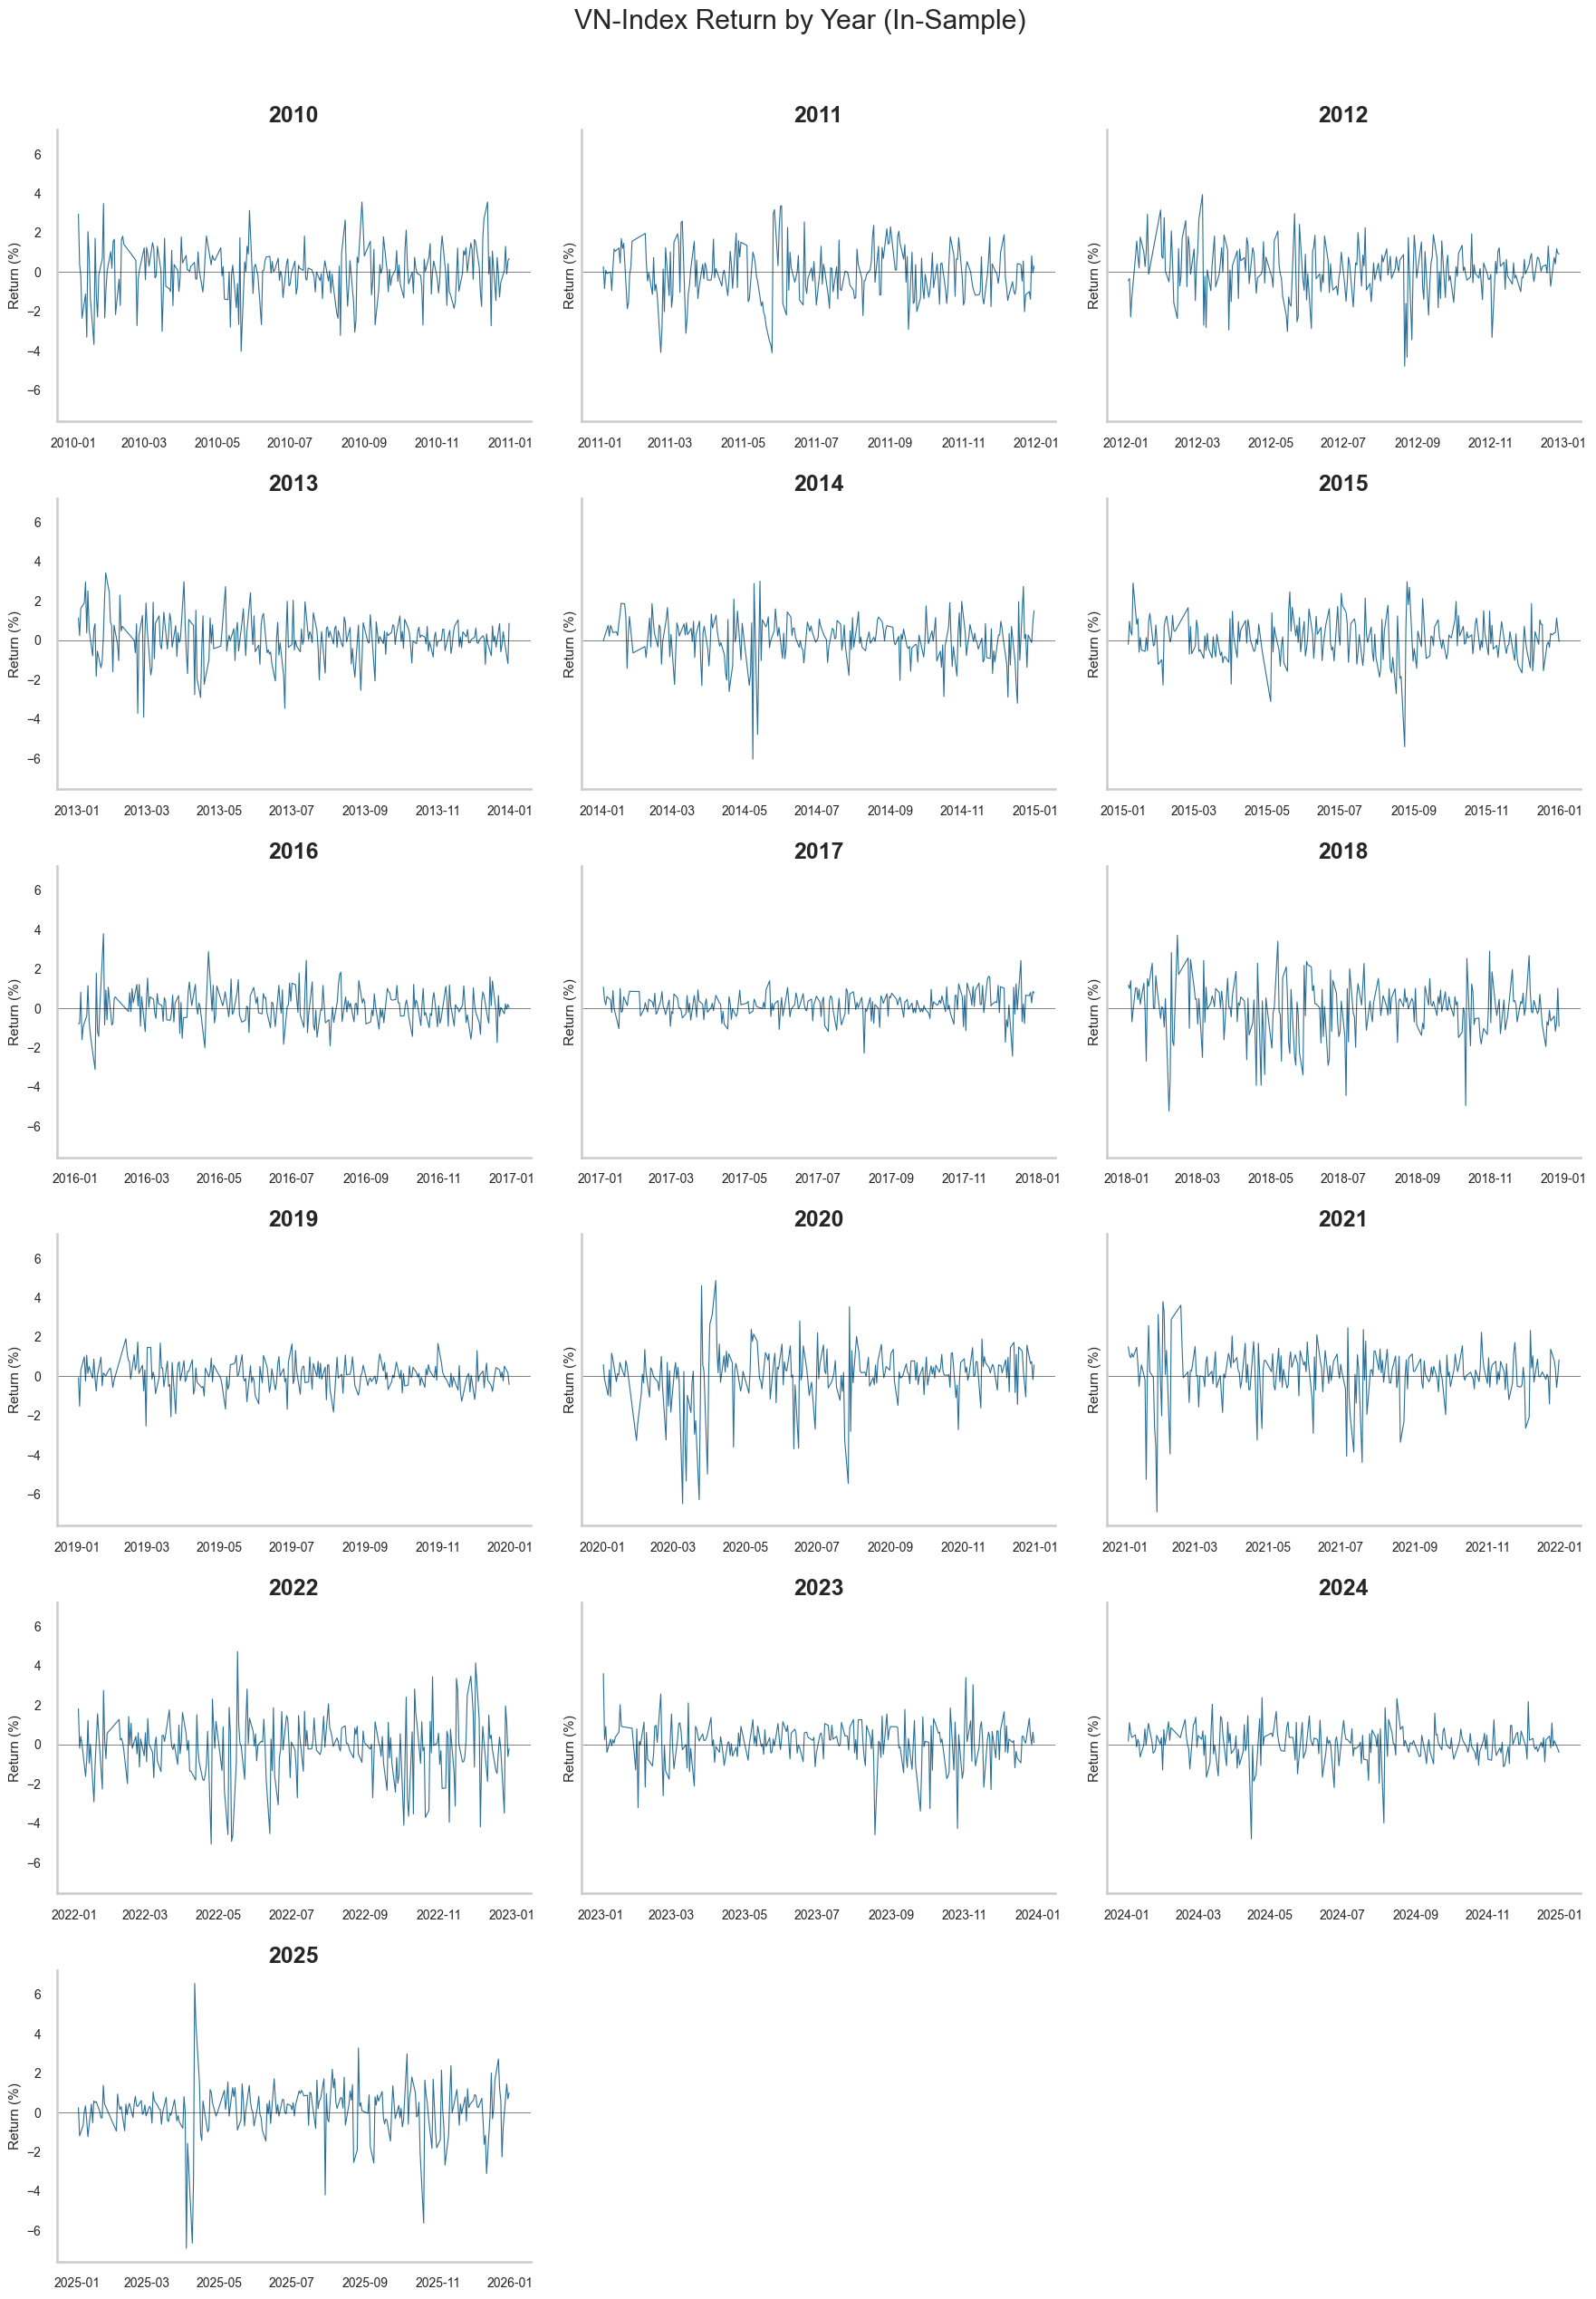

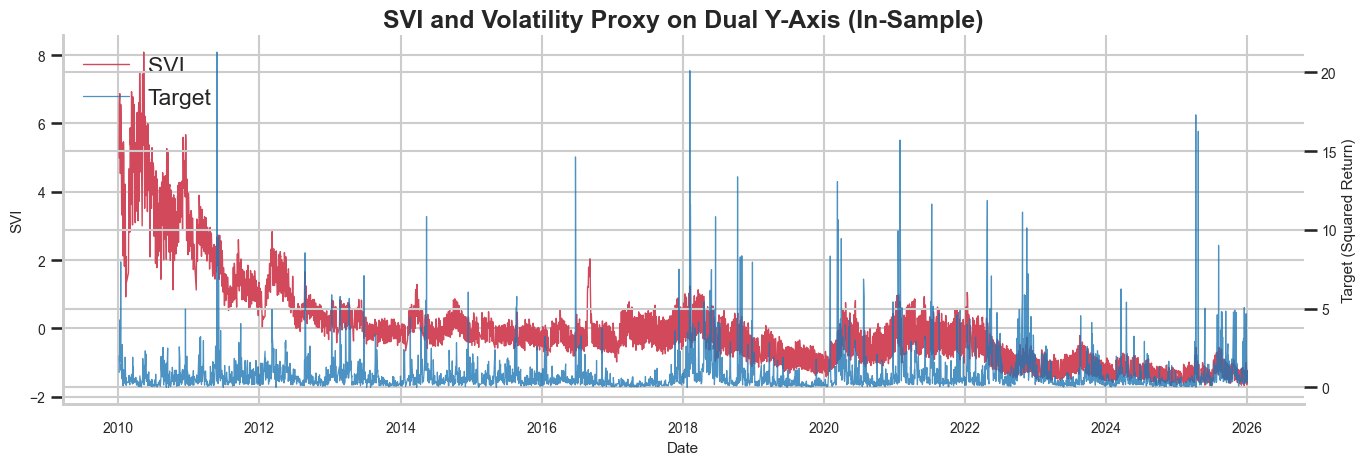

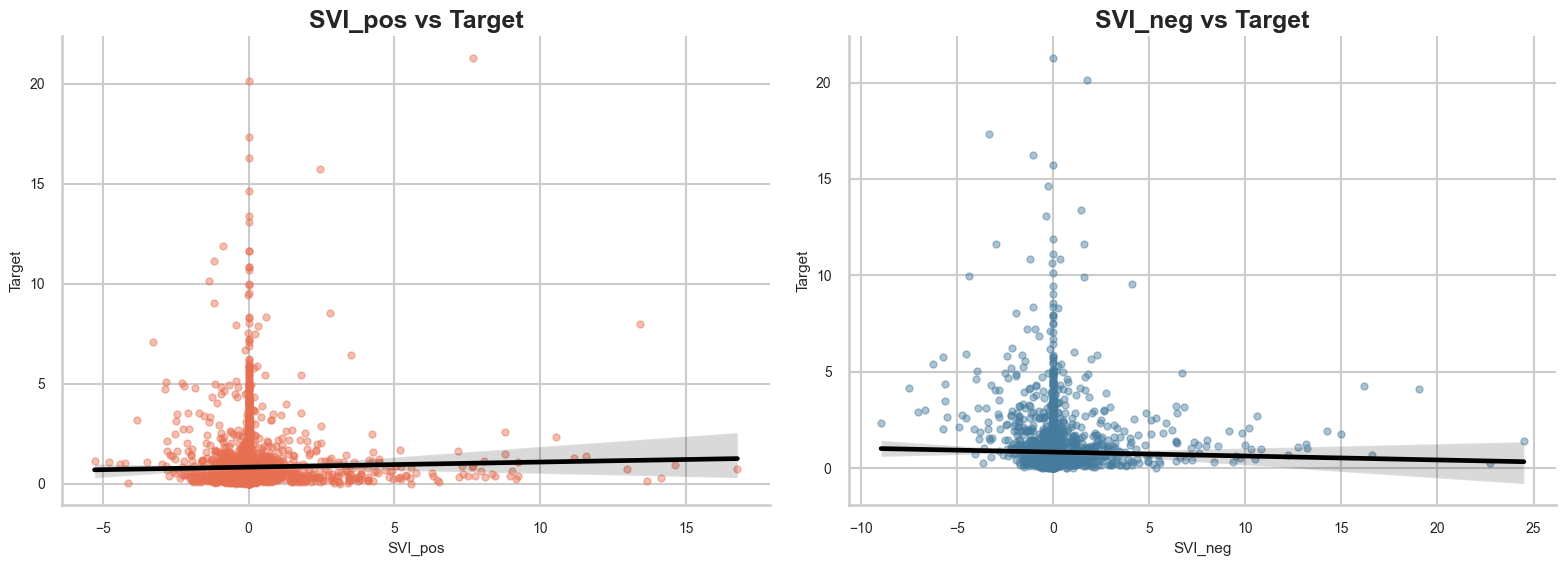

In [6]:
def _set_scientific_plot_style() -> None:
    sns.set_theme(style="whitegrid", context="talk")
    plt.rcParams.update({
        "figure.figsize": (12, 6),
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.titleweight": "bold",
        "axes.labelsize": 11,
        "xtick.labelsize": 10,
        "ytick.labelsize": 10,
        "legend.frameon": False,
    })


def plot_keyword_correlation_heatmap(keyword_df: pd.DataFrame) -> None:
    _set_scientific_plot_style()
    corr = keyword_df.corr(method="pearson")
    _, ax = plt.subplots(figsize=(9, 7))
    sns.heatmap(
        corr,
        ax=ax,
        cmap="RdBu_r",
        vmin=-1,
        vmax=1,
        center=0,
        annot=True,
        fmt=".2f",
        linewidths=0.5,
        square=True,
        cbar_kws={"shrink": 0.8},
    )
    ax.set_title("Correlation Heatmap of Google Trends Keywords")
    ax.set_xlabel("")
    ax.set_ylabel("")
    plt.tight_layout()
    plt.show()


def plot_return_series(df: pd.DataFrame) -> None:
    _set_scientific_plot_style()
    _, ax = plt.subplots(figsize=(14, 5))
    ax.grid(False)
    ax.plot(df.index, df["return"], color="#1f77b4", linewidth=0.9)
    ax.set_title("VN-Index Log Return Over In-Sample Period")
    ax.set_xlabel("Date")
    ax.set_ylabel("Return (%)")
    ax.axhline(0, color="black", linewidth=0.8, alpha=0.6)
    plt.tight_layout()
    plt.show()


def plot_return_by_year(df: pd.DataFrame) -> None:
    _set_scientific_plot_style()
    years = sorted(df.index.year.unique())
    ncols = 3
    nrows = int(np.ceil(len(years) / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(18, 4.2 * nrows), sharey=True)
    axes = np.array(axes).reshape(-1)

    for ax, year in zip(axes, years):
        yearly = df[df.index.year == year]
        ax.grid(False)
        ax.plot(yearly.index, yearly["return"], color="#2a6f97", linewidth=0.8)
        ax.axhline(0, color="black", linewidth=0.7, alpha=0.5)
        ax.set_title(str(year))
        ax.set_xlabel("")
        ax.set_ylabel("Return (%)")

    for ax in axes[len(years):]:
        ax.axis("off")

    fig.suptitle("VN-Index Return by Year (In-Sample)", y=1.01)
    plt.tight_layout()
    plt.show()


def plot_svi_target_dual_axis(df: pd.DataFrame) -> None:
    _set_scientific_plot_style()
    _, ax1 = plt.subplots(figsize=(14, 5))
    ax2 = ax1.twinx()

    line1 = ax1.plot(df.index, df["SVI"], color="#d1495b", linewidth=1.0, label="SVI")
    line2 = ax2.plot(df.index, df["target"], color="#1f77b4", linewidth=0.9, alpha=0.8, label="Target")

    ax1.set_title("SVI and Volatility Proxy on Dual Y-Axis (In-Sample)")
    ax1.set_xlabel("Date")
    ax1.set_ylabel("SVI")
    ax2.set_ylabel("Target (Squared Return)")

    lines = line1 + line2
    labels = [line.get_label() for line in lines]
    ax1.legend(lines, labels, loc="upper left")
    plt.tight_layout()
    plt.show()


def plot_svi_scatter_relationships(df: pd.DataFrame) -> None:
    _set_scientific_plot_style()
    _, axes = plt.subplots(1, 2, figsize=(16, 6))

    sns.regplot(data=df, x="SVI_pos", y="target", ax=axes[0], scatter_kws={"alpha": 0.45, "s": 25}, line_kws={"color": "black"}, color="#e76f51")
    axes[0].set_title("SVI_pos vs Target")
    axes[0].set_xlabel("SVI_pos")
    axes[0].set_ylabel("Target")

    sns.regplot(data=df, x="SVI_neg", y="target", ax=axes[1], scatter_kws={"alpha": 0.45, "s": 25}, line_kws={"color": "black"}, color="#457b9d")
    axes[1].set_title("SVI_neg vs Target")
    axes[1].set_xlabel("SVI_neg")
    axes[1].set_ylabel("Target")

    plt.tight_layout()
    plt.show()


plot_keyword_correlation_heatmap(keyword_insample)
plot_return_series(insample_df)
plot_return_by_year(insample_df)
plot_svi_target_dual_axis(insample_df)
plot_svi_scatter_relationships(insample_df)